# Simulación de Observables Cuánticos

## Taller de Teoría Cuántica Básica, Observables y Mediciones

**Author**: Sara Sofia Gonzalez  
**Curso**: CNYT 
**Institución** : Escuela Colombiana de Ingeniería Julio Garavito 

### Descripción del Proyecto

Este cuaderno implementa un simulador completo de sistemas cuánticos basado en la teoría del Capítulo 4, que cubre:

Modelado de sistemas cuánticos con posiciones discretas de partículas
Mediciones de observables y cálculos de probabilidad
Cálculo de probabilidades de transición entre estados
Validación de matrices hermitianas y análisis estadístico
Cálculo de valores propios y transiciones de estados cuánticos
Evolución dinámica del sistema mediante transformaciones unitarias
Ensamblaje de sistemas cuánticos de múltiples partículas

### Requisitos Técnicos

La simulación aborda los siguientes ejercicios:
4.3.1: Análisis de transición de estados después de la medición
4.3.2: Cálculo de probabilidades para el colapso del estado cuántico
4.4.1: Verificación y composición de matrices unitarias
4.4.2: Evolución del sistema cuántico a través de múltiples pasos de tiempo
4.5.2: Generalización del vector de estado para múltiples partículas
4.5.3: Análisis de separabilidad de estados cuánticos

## 1. Configuración del Entorno y Dependencias

Configuración del entorno de desarrollo con los paquetes necesarios para tareas de computación cuántica. Esta sección asegura que todas las dependencias requeridas estén correctamente instaladas y configuradas.

In [ ]:
# Configuración del entorno y gestión de dependencias
import sys
import subprocess
import pkg_resources
from pathlib import Path

def install_package(package_name):
    """
    Instala un paquete si no está ya instalado
    
    Args:
        package_name (str): Nombre del paquete a instalar
    """
    try:
        pkg_resources.get_distribution(package_name)
        print(f"✓ {package_name} ya está instalado")
    except pkg_resources.DistributionNotFound:
        print(f"Instalando {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        print(f"✓ {package_name} instalado correctamente")

# Paquetes requeridos para computación cuántica
required_packages = [
    'numpy',
    'scipy', 
    'matplotlib',
    'jupyter',
    'sympy'
]

print("=== Configuración del Entorno para Simulación de Observables Cuánticos ===")
print("Verificando e instalando dependencias necesarias...\n")

for package in required_packages:
    install_package(package)

print("\n=== Configuración del Entorno Completa ===")
print("Todos los paquetes necesarios están disponibles para tareas de computación cuántica.")

## 2. Importar las bibliotecas y módulos requeridos
Importación de las bibliotecas esenciales de Python para la computación cuántica, incluyendo NumPy para operaciones de álgebra lineal, SciPy para funciones matemáticas avanzadas y matplotlib para visualización.

In [ ]:
# Bibliotecas principales de matemáticas y computación científica
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
import sympy as sp
from sympy import symbols, I, sqrt, Matrix, simplify, expand, factor
import warnings
warnings.filterwarnings('ignore')

# Importaciones de la biblioteca estándar
import math
import cmath
from fractions import Fraction
from typing import List, Tuple, Union, Optional, Any
import json

# Visualización y formato
from IPython.display import display, Markdown, HTML, Latex
import pandas as pd

# Configurar matplotlib para gráficos de alta calidad
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("=== Bibliotecas principales importadas correctamente ===")
print("• NumPy: Álgebra lineal y operaciones con arreglos")
print("• SciPy: Funciones matemáticas avanzadas") 
print("• Matplotlib: Visualización de datos y gráficos")
print("• SymPy: Matemáticas simbólicas y notación cuántica")
print("• IPython: Capacidades avanzadas de visualización")
print("✓ Todas las bibliotecas listas para tareas de computación cuántica")

## 3. Cargar el módulo Transcription Quantum Chapter

Cargando el módulo transcription_quantum_chapter para acceder a definiciones de problemas, contenido teórico y funciones auxiliares para los ejercicios 4.3.1, 4.3.2, 4.4.1, 4.4.2, 4.5.2 y 4.5.3.

In [ ]:
# Cargar el módulo transcription quantum chapter
import sys
import os

# Agregar el directorio actual al path de Python para importar el módulo
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)

try:
    import transcription_quantum_chapter as tqc
    print("=== Módulo Transcription Quantum Chapter Cargado ===")
    print("✓ Módulo importado correctamente")
    
    # Mostrar secciones de contenido disponibles
    print("\nSecciones de contenido disponibles:")
    for key in tqc.content.keys():
        print(f"• {key}")
    
    print(f"\nTotal de secciones disponibles: {len(tqc.content)}")
    
except ImportError as e:
    print(f"Error al importar transcription_quantum_chapter: {e}")
    print("Continuando con implementación directa...")
    
    # Definir contenido esencial si falla la importación del módulo
    class TranscriptionContent:
        """Contenedor de contenido alternativo para transcripciones de teoría cuántica"""
        
        def get_exercise(self, exercise_name):
            """Retorna el contenido del ejercicio por nombre"""
            exercises = {
                '4.3.1': """Ejercicio 4.3.1: Encontrar todos los posibles estados a los que el sistema puede transicionar después de la medición""",
                '4.3.2': """Ejemplo 4.3.2: Calcular probabilidades para el colapso del vector de estado a autovectores""",
                '4.4.1': """Ejercicio 4.4.1: Verificar matrices unitarias y su composición""",
                '4.4.2': """Ejercicio 4.4.2: Evolución de una bola de billar cuántica a lo largo de pasos de tiempo""",
                '4.5.2': """Ejercicio 4.5.2: Vector de estado genérico para un sistema de espín de dos partículas""",
                '4.5.3': """Ejercicio 4.5.3: Analizar la separabilidad del estado en sistemas cuánticos"""
            }
            return exercises.get(exercise_name, "Ejercicio no encontrado")
    
    tqc = TranscriptionContent()
    print("✓ Estructura de contenido alternativa inicializada")

print("\n=== Carga del módulo completada ===")
print("Listo para acceder a ejercicios y ejemplos de teoría cuántica")

## 6. Clase Extendida del Simulador de Sistema Cuántico

Simulador de sistema cuántico extendido que se basa en la implementación básica de la Sección 4.1 para manejar los ejercicios específicos del marco teórico. Esta clase integra toda la funcionalidad necesaria para los ejercicios 4.3.1, 4.3.2, 4.4.1, 4.4.2, 4.5.2 y 4.5.3.

## 4. Sección 4.1 - Simulador Básico de Sistema Cuántico

Implementación del primer sistema cuántico descrito en la sección 4.1: una partícula confinada a un conjunto discreto de posiciones en una línea. El simulador permite especificar el número de posiciones y un vector de estado ket asignando las amplitudes.

In [ ]:
class DiscreteQuantumSystem:
    """
    Simulador básico de sistema cuántico para la sección 4.1.
    
    Modela una partícula confinada a un conjunto discreto de posiciones en una línea.
    Permite especificar el número de posiciones y el vector de estado con amplitudes.
    """
    
    def __init__(self, num_positions):
        """
        Inicializa el sistema cuántico con el número de posiciones especificado.
        
        Args:
            num_positions (int): Número de posiciones discretas disponibles
        """
        self.num_positions = num_positions
        self.state_vector = None
        
        print(f"=== Sistema Cuántico Discreto Inicializado ===")
        print(f"Número de posiciones: {num_positions}")
        print(f"Dimensión del espacio de Hilbert: {num_positions}")
    
    def set_state_vector(self, amplitudes):
        """
        Establece el vector de estado cuántico con las amplitudes dadas.
        
        Args:
            amplitudes (list o np.array): Amplitudes complejas para cada posición
        """
        amplitudes = np.array(amplitudes, dtype=complex)
        
        if len(amplitudes) != self.num_positions:
            raise ValueError(f"El vector de estado debe tener {self.num_positions} amplitudes")
        
        # Normalizar el vector de estado
        norm = np.linalg.norm(amplitudes)
        if norm == 0:
            raise ValueError("El vector de estado no puede ser cero")
        
        self.state_vector = amplitudes / norm
        
        print(f"Vector de estado establecido: {self.state_vector}")
        print(f"Verificación de normalización: |ψ|² = {np.sum(np.abs(self.state_vector)**2):.6f}")
    
    def probability_at_position(self, position):
        """
        Calcula la probabilidad de encontrar la partícula en una posición específica.
        
        Args:
            position (int): Índice de la posición (0 a num_positions-1)
            
        Returns:
            float: Probabilidad de encontrar la partícula en la posición dada
        """
        if self.state_vector is None:
            raise ValueError("Vector de estado no establecido")
        
        if position < 0 or position >= self.num_positions:
            raise ValueError(f"La posición debe estar entre 0 y {self.num_positions-1}")
        
        probability = np.abs(self.state_vector[position])**2
        
        print(f"Probabilidad en la posición {position}:")
        print(f"  Amplitud: {self.state_vector[position]}")
        print(f"  |α_{position}|² = {probability:.6f}")
        
        return probability
    
    def transition_probability(self, final_state):
        """
        Calcula la probabilidad de transición del estado actual a un estado final.
        
        Args:
            final_state (list o np.array): Vector de estado final
            
        Returns:
            float: Probabilidad de transición |⟨φ|ψ⟩|²
        """
        if self.state_vector is None:
            raise ValueError("Vector de estado inicial no establecido")
        
        final_state = np.array(final_state, dtype=complex)
        
        if len(final_state) != self.num_positions:
            raise ValueError(f"El estado final debe tener {self.num_positions} amplitudes")
        
        # Normalizar el estado final
        final_norm = np.linalg.norm(final_state)
        if final_norm == 0:
            raise ValueError("El vector de estado final no puede ser cero")
        
        final_state_normalized = final_state / final_norm
        
        # Calcular el producto interno ⟨φ|ψ⟩
        inner_product = np.vdot(final_state_normalized, self.state_vector)
        transition_prob = np.abs(inner_product)**2
        
        print(f"Calculando probabilidad de transición:")
        print(f"  Estado inicial |ψ⟩ = {self.state_vector}")
        print(f"  Estado final |φ⟩ = {final_state_normalized}")
        print(f"  Producto interno ⟨φ|ψ⟩ = {inner_product}")
        print(f"  Probabilidad de transición |⟨φ|ψ⟩|² = {transition_prob:.6f}")
        
        return transition_prob
    
    def display_system_info(self):
        """Muestra la información completa del sistema."""
        print(f"\n=== Información del Sistema Cuántico ===")
        print(f"Número de posiciones: {self.num_positions}")
        print(f"Dimensión del espacio de Hilbert: {self.num_positions}")
        
        if self.state_vector is not None:
            print(f"Estado actual: {self.state_vector}")
            print(f"Norma del estado: {np.linalg.norm(self.state_vector):.6f}")
            
            print(f"\nProbabilidades por posición:")
            for i in range(self.num_positions):
                prob = np.abs(self.state_vector[i])**2
                print(f"  Posición {i}: {prob:.6f} ({prob*100:.2f}%)")

# Prueba del sistema cuántico básico
print("=== Probando el Sistema Cuántico Básico (Sección 4.1) ===")

# Crear un sistema cuántico de 3 posiciones
quantum_sys = DiscreteQuantumSystem(3)

# Establecer el vector de estado inicial
initial_amplitudes = [1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3)]
quantum_sys.set_state_vector(initial_amplitudes)

# Probar cálculos de probabilidad
print("\n--- Probando probabilidades por posición ---")
for pos in range(3):
    quantum_sys.probability_at_position(pos)

# Probar probabilidad de transición
print("\n--- Probando probabilidad de transición ---")
final_state = [1, 0, 0]  # La partícula está definitivamente en la posición 0
transition_prob = quantum_sys.transition_probability(final_state)

# Mostrar información completa del sistema
quantum_sys.display_system_info()

print("\n=== Implementación de la Sección 4.1 Completa ===")
print("✓ Sistema cuántico de posiciones discretas implementado")
print("✓ Cálculo de probabilidades por posición verificado")
print("✓ Cálculo de probabilidad de transición verificado")

=== Testing Section 4.1 Basic Quantum System ===
=== Discrete Quantum System Initialized ===
Number of positions: 3
Hilbert space dimension: 3
State vector set: [0.57735027+0.j 0.57735027+0.j 0.57735027+0.j]
Normalization check: |ψ|² = 1.000000

--- Testing position probabilities ---
Probability at position 0:
  Amplitude: (0.5773502691896258+0j)
  |α_0|² = 0.333333
Probability at position 1:
  Amplitude: (0.5773502691896258+0j)
  |α_1|² = 0.333333
Probability at position 2:
  Amplitude: (0.5773502691896258+0j)
  |α_2|² = 0.333333

--- Testing transition probability ---
Transition probability calculation:
  Initial state |ψ⟩ = [0.57735027+0.j 0.57735027+0.j 0.57735027+0.j]
  Final state |φ⟩ = [1.+0.j 0.+0.j 0.+0.j]
  Inner product ⟨φ|ψ⟩ = (0.5773502691896258+0j)
  Transition probability |⟨φ|ψ⟩|² = 0.333333

=== Quantum System Information ===
Number of positions: 3
Hilbert space dimension: 3
Current state: [0.57735027+0.j 0.57735027+0.j 0.57735027+0.j]
State norm: 1.000000

Position pro

## 5. Retos de Programación del Capítulo 4

Implementación de los cuatro retos de programación del Capítulo 4:

Cálculo de amplitud de transición
Análisis de observables (verificación hermítica, media, varianza)
Cálculo de probabilidades de valores propios y vectores propios
Dinámica del sistema con evolución unitaria

In [ ]:
class QuantumProgrammingChallenges:
    """
    Implementación de los Retos de Programación del Capítulo 4.
    
    Cuatro funcionalidades principales:
    1. Cálculo de amplitud de transición
    2. Análisis de observables (verificación hermítica, media, varianza)
    3. Probabilidades de valores propios después de la medición
    4. Dinámica del sistema con matrices unitarias
    """
    
    @staticmethod
    def transition_amplitude(state1, state2):
        """
        Reto 1: Calcular la amplitud de transición entre dos estados.
        
        Args:
            state1 (np.array): Vector de estado inicial |ψ⟩
            state2 (np.array): Vector de estado final |φ⟩
            
        Returns:
            tuple: (amplitud, probabilidad) donde amplitud = ⟨φ|ψ⟩ y prob = |⟨φ|ψ⟩|²
        """
        state1 = np.array(state1, dtype=complex)
        state2 = np.array(state2, dtype=complex)
        
        # Normalizar estados
        state1_norm = state1 / np.linalg.norm(state1)
        state2_norm = state2 / np.linalg.norm(state2)
        
        # Calcular amplitud de transición ⟨φ|ψ⟩
        amplitude = np.vdot(state2_norm, state1_norm)
        probability = np.abs(amplitude)**2
        
        print(f"=== Reto de Programación 1: Amplitud de Transición ===")
        print(f"Estado inicial |ψ⟩: {state1_norm}")
        print(f"Estado final |φ⟩: {state2_norm}")
        print(f"Amplitud de transición ⟨φ|ψ⟩: {amplitude}")
        print(f"Probabilidad de transición |⟨φ|ψ⟩|²: {probability:.6f}")
        
        return amplitude, probability
    
    @staticmethod
    def observable_analysis(observable_matrix, state_vector):
        """
        Reto 2: Analizar propiedades del observable y calcular estadísticas.
        
        Args:
            observable_matrix (np.array): Matriz observable Ω
            state_vector (np.array): Estado cuántico |ψ⟩
            
        Returns:
            dict: Resultados del análisis incluyendo verificación hermítica, media, varianza
        """
        omega = np.array(observable_matrix, dtype=complex)
        state = np.array(state_vector, dtype=complex)
        state = state / np.linalg.norm(state)  # Normalizar
        
        print(f"=== Reto de Programación 2: Análisis de Observable ===")
        
        # Verificar si la matriz es hermítica
        is_hermitian = np.allclose(omega, omega.conj().T)
        print(f"Verificación hermítica: {is_hermitian}")
        
        if not is_hermitian:
            print("⚠️  La matriz no es hermítica - ¡no es un observable válido!")
            return {"hermitian": False, "mean": None, "variance": None}
        
        # Calcular valor esperado ⟨ψ|Ω|ψ⟩
        mean_value = np.real(np.vdot(state, omega @ state))
        
        # Calcular ⟨ψ|Ω²|ψ⟩
        omega_squared = omega @ omega
        mean_squared = np.real(np.vdot(state, omega_squared @ state))
        
        # Calcular varianza
        variance = mean_squared - mean_value**2
        std_deviation = np.sqrt(variance)
        
        print(f"Matriz observable Ω:")
        print(omega)
        print(f"Estado |ψ⟩: {state}")
        print(f"Valor esperado ⟨Ω⟩ = ⟨ψ|Ω|ψ⟩: {mean_value:.6f}")
        print(f"⟨Ω²⟩ = ⟨ψ|Ω²|ψ⟩: {mean_squared:.6f}")
        print(f"Varianza Var(Ω) = ⟨Ω²⟩ - ⟨Ω⟩²: {variance:.6f}")
        print(f"Desviación estándar σ: {std_deviation:.6f}")
        
        return {
            "hermitian": True,
            "mean": mean_value,
            "variance": variance,
            "std_deviation": std_deviation,
            "mean_squared": mean_squared
        }
    
    @staticmethod
    def eigenvalue_probabilities(observable_matrix, state_vector):
        """
        Reto 3: Calcular valores propios y probabilidades de transición a autovectores.
        
        Args:
            observable_matrix (np.array): Matriz observable Ω
            state_vector (np.array): Estado cuántico |ψ⟩
            
        Returns:
            dict: Valores propios, autovectores y probabilidades de transición
        """
        omega = np.array(observable_matrix, dtype=complex)
        state = np.array(state_vector, dtype=complex)
        state = state / np.linalg.norm(state)  # Normalizar
        
        print(f"=== Reto de Programación 3: Análisis de Valores Propios ===")
        
        # Calcular valores y vectores propios
        eigenvalues, eigenvectors = np.linalg.eigh(omega)
        
        print(f"Análisis espectral de la matriz observable:")
        print(f"Valores propios: {eigenvalues}")
        
        # Calcular probabilidades de transición a cada autovector
        probabilities = []
        for i, eigenvector in enumerate(eigenvectors.T):
            # Normalizar autovector
            eigenvector = eigenvector / np.linalg.norm(eigenvector)
            
            # Calcular probabilidad de transición
            amplitude = np.vdot(eigenvector, state)
            probability = np.abs(amplitude)**2
            probabilities.append(probability)
            
            print(f"Valor propio λ_{i+1} = {eigenvalues[i]:.6f}")
            print(f"  Autovector |e_{i+1}⟩: {eigenvector}")
            print(f"  Amplitud de transición ⟨e_{i+1}|ψ⟩: {amplitude}")
            print(f"  Probabilidad de transición: {probability:.6f}")
        
        # Verificar que las probabilidades sumen 1
        total_prob = sum(probabilities)
        print(f"\\nProbabilidad total: {total_prob:.6f}")
        print(f"Conservación de probabilidad: {'✓' if np.isclose(total_prob, 1.0) else '✗'}")
        
        return {
            "eigenvalues": eigenvalues,
            "eigenvectors": eigenvectors.T,
            "probabilities": probabilities,
            "total_probability": total_prob
        }
    
    @staticmethod
    def system_dynamics(initial_state, unitary_matrices):
        """
        Reto 4: Calcular el estado final después de una serie de transformaciones unitarias.
        
        Args:
            initial_state (np.array): Estado cuántico inicial |ψ₀⟩
            unitary_matrices (list): Serie de matrices unitarias [U₁, U₂, ..., Uₙ]
            
        Returns:
            tuple: (estado_final, estados_intermedios)
        """
        state = np.array(initial_state, dtype=complex)
        state = state / np.linalg.norm(state)  # Normalizar estado inicial
        
        print(f"=== Reto de Programación 4: Dinámica del Sistema ===")
        print(f"Estado inicial |ψ₀⟩: {state}")
        
        evolution_states = [state.copy()]
        
        # Aplicar cada transformación unitaria secuencialmente
        for i, unitary in enumerate(unitary_matrices):
            U = np.array(unitary, dtype=complex)
            
            # Verificar unitariedad
            is_unitary = np.allclose(U @ U.conj().T, np.eye(U.shape[0]))
            if not is_unitary:
                print(f"⚠️  La matriz U_{i+1} no es unitaria!")
                continue
            
            # Aplicar transformación
            state = U @ state
            evolution_states.append(state.copy())
            
            print(f"\\nPaso {i+1}:")
            print(f"  Matriz unitaria U_{i+1}:")
            for row in U:
                print(f"    {row}")
            print(f"  Estado después de U_{i+1}: |ψ_{i+1}⟩ = {state}")
            print(f"  Verificación de norma: {np.linalg.norm(state):.6f}")
        
        print(f"\\nEstado final |ψ_final⟩: {state}")
        print(f"Norma del estado final: {np.linalg.norm(state):.6f}")
        
        return state, evolution_states

# Prueba de todos los retos de programación
print("=== Probando Retos de Programación del Capítulo 4 ===\\n")

# Reto 1: Amplitud de transición
print("--- Prueba Reto 1 ---")
state_a = [1, 0, 0]
state_b = [0, 1, 0] 
amplitude, prob = QuantumProgrammingChallenges.transition_amplitude(state_a, state_b)

print("\\n--- Prueba Reto 1 (Estados no ortogonales) ---")
state_c = [1/np.sqrt(2), 1/np.sqrt(2), 0]
state_d = [1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3)]
amplitude2, prob2 = QuantumProgrammingChallenges.transition_amplitude(state_c, state_d)

# Reto 2: Análisis de observable
print("\\n--- Prueba Reto 2 ---")
observable = np.array([[1, 1j], [-1j, -1]], dtype=complex)
test_state = [1/np.sqrt(2), 1/np.sqrt(2)]
analysis = QuantumProgrammingChallenges.observable_analysis(observable, test_state)

# Reto 3: Probabilidades de valores propios
print("\\n--- Prueba Reto 3 ---")
pauli_z = np.array([[1, 0], [0, -1]], dtype=complex)
superposition = [1/np.sqrt(2), 1/np.sqrt(2)]
eigen_analysis = QuantumProgrammingChallenges.eigenvalue_probabilities(pauli_z, superposition)

# Reto 4: Dinámica del sistema
print("\\n--- Prueba Reto 4 ---")
initial = [1, 0]
hadamard = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
pauli_x = np.array([[0, 1], [1, 0]], dtype=complex)
unitary_sequence = [hadamard, pauli_x]

final_state, evolution = QuantumProgrammingChallenges.system_dynamics(initial, unitary_sequence)

print("\\n=== Todos los Retos de Programación Completados ===")
print("✓ Reto 1: Cálculo de amplitud de transición implementado")
print("✓ Reto 2: Análisis de observables con verificación hermítica implementado")
print("✓ Reto 3: Cálculo de probabilidades de valores propios implementado") 
print("✓ Reto 4: Dinámica del sistema con evolución unitaria implementado")

=== Testing Chapter 4 Programming Challenges ===\n
--- Challenge 1 Test ---
=== Programming Challenge 1: Transition Amplitude ===
Initial state |ψ⟩: [1.+0.j 0.+0.j 0.+0.j]
Final state |φ⟩: [0.+0.j 1.+0.j 0.+0.j]
Transition amplitude ⟨φ|ψ⟩: 0j
Transition probability |⟨φ|ψ⟩|²: 0.000000
\n--- Challenge 1 Test (Non-orthogonal states) ---
=== Programming Challenge 1: Transition Amplitude ===
Initial state |ψ⟩: [0.70710678+0.j 0.70710678+0.j 0.        +0.j]
Final state |φ⟩: [0.57735027+0.j 0.57735027+0.j 0.57735027+0.j]
Transition amplitude ⟨φ|ψ⟩: (0.8164965809277261+0j)
Transition probability |⟨φ|ψ⟩|²: 0.666667
\n--- Challenge 2 Test ---
=== Programming Challenge 2: Observable Analysis ===
Hermitian check: True
Observable matrix Ω:
[[ 1.+0.j  0.+1.j]
 [-0.-1.j -1.+0.j]]
State |ψ⟩: [0.70710678+0.j 0.70710678+0.j]
Mean value ⟨Ω⟩ = ⟨ψ|Ω|ψ⟩: 0.000000
⟨Ω²⟩ = ⟨ψ|Ω²|ψ⟩: 2.000000
Variance Var(Ω) = ⟨Ω²⟩ - ⟨Ω⟩²: 2.000000
Standard deviation σ: 1.414214
\n--- Challenge 3 Test ---
=== Programming Challe

In [ ]:
class QuantumSystemSimulator:
    """
    Simulador de Sistema Cuántico para posiciones discretas.
    
    Esta clase implementa el sistema cuántico fundamental descrito en la sección 4.1,
    que consiste en una partícula confinada a posiciones discretas en una línea.
    
    Atributos:
        num_positions (int): Número de posiciones discretas disponibles
        state_vector (np.ndarray): Vector de estado (ket) de valores complejos
        is_normalized (bool): Indica si el vector de estado está normalizado
    """
    
    def __init__(self, num_positions: int, amplitudes: List[complex] = None):
        """
        Inicializa el sistema cuántico con posiciones y amplitudes especificadas.
        
        Args:
            num_positions (int): Número de posiciones discretas en la línea
            amplitudes (List[complex], opcional): Amplitudes iniciales del estado
        
        Raises:
            ValueError: Si la longitud de amplitudes no coincide con las posiciones
        """
        self.num_positions = num_positions
        
        if amplitudes is None:
            # Inicializar con amplitudes de probabilidad iguales
            amplitude_value = 1.0 / np.sqrt(num_positions) 
            self.state_vector = np.array([amplitude_value] * num_positions, dtype=complex)
        else:
            if len(amplitudes) != num_positions:
                raise ValueError(f"La longitud de amplitudes ({len(amplitudes)}) debe coincidir con posiciones ({num_positions})")
            self.state_vector = np.array(amplitudes, dtype=complex)
        
        self.is_normalized = self._check_normalization()
        
        print(f"=== Sistema Cuántico Inicializado ===")
        print(f"Posiciones: {self.num_positions}")
        print(f"Vector de estado: {self.state_vector}")
        print(f"Normalizado: {self.is_normalized}")
    
    def _check_normalization(self, tolerance: float = 1e-10) -> bool:
        """
        Verifica si el vector de estado está normalizado.
        
        Args:
            tolerance (float): Tolerancia numérica para la verificación
            
        Returns:
            bool: True si está normalizado, False en caso contrario
        """
        norm_squared = np.sum(np.abs(self.state_vector)**2)
        return abs(norm_squared - 1.0) < tolerance
    
    def normalize_state(self) -> None:
        """
        Normaliza el vector de estado actual.
        
        Modifica el vector en el lugar para asegurar norma unitaria.
        """
        norm = np.linalg.norm(self.state_vector)
        if norm > 0:
            self.state_vector = self.state_vector / norm
            self.is_normalized = True
            print(f"✓ Vector de estado normalizado (norma = {norm:.6f})")
        else:
            raise ValueError("No se puede normalizar el vector cero")
    
    def get_position_probability(self, position: int) -> float:
        """
        Calcula la probabilidad de encontrar la partícula en una posición dada.
        
        Args:
            position (int): Índice de la posición (desde 0)
            
        Returns:
            float: Probabilidad de encontrar la partícula en esa posición
            
        Raises:
            IndexError: Si la posición está fuera de rango
        """
        if not 0 <= position < self.num_positions:
            raise IndexError(f"Posición {position} fuera de rango [0, {self.num_positions-1}]")
        
        probability = np.abs(self.state_vector[position])**2
        return float(probability)
    
    def get_all_probabilities(self) -> np.ndarray:
        """
        Calcula las probabilidades para todas las posiciones.
        
        Returns:
            np.ndarray: Arreglo de probabilidades por posición
        """
        return np.abs(self.state_vector)**2
    
    def transition_probability(self, target_state: 'QuantumSystemSimulator') -> float:
        """
        Calcula la probabilidad de transición al estado objetivo.
        
        Args:
            target_state (QuantumSystemSimulator): Estado cuántico objetivo
            
        Returns:
            float: Probabilidad de transición |<objetivo|actual>|²
            
        Raises:
            ValueError: Si los sistemas tienen dimensiones incompatibles
        """
        if self.num_positions != target_state.num_positions:
            raise ValueError("Los sistemas deben tener el mismo número de posiciones")
        
        # Calcular producto interno <objetivo|actual>
        inner_product = np.vdot(target_state.state_vector, self.state_vector)
        
        # Retornar el cuadrado del módulo
        transition_prob = np.abs(inner_product)**2
        return float(transition_prob)
    
    def display_state_info(self) -> None:
        """Muestra información completa del estado cuántico."""
        print("=== Información del Estado Cuántico ===")
        print(f"Dimensión del sistema: {self.num_positions}")
        print(f"Vector de estado: {self.state_vector}")
        print(f"Normalizado: {self.is_normalized}")
        print(f"Norma del estado: {np.linalg.norm(self.state_vector):.6f}")
        
        print("\nProbabilidades por posición:")
        for i in range(self.num_positions):
            prob = self.get_position_probability(i)
            print(f"  Posición {i}: {prob:.6f} ({prob*100:.2f}%)")
        
        total_prob = np.sum(self.get_all_probabilities())
        print(f"Probabilidad total: {total_prob:.6f}")

# Probar el simulador de sistema cuántico
print("=== Probando el Simulador de Sistema Cuántico ===")
test_amplitudes = [1/np.sqrt(2), 1j/np.sqrt(2)]
test_system = QuantumSystemSimulator(2, test_amplitudes)
test_system.display_state_info()

=== Testing Quantum System Simulator ===
=== Quantum System Initialized ===
Positions: 2
State vector: [0.70710678+0.j         0.        +0.70710678j]
Normalized: True
=== Quantum State Information ===
System dimension: 2
State vector: [0.70710678+0.j         0.        +0.70710678j]
Normalized: True
State norm: 1.000000

Position probabilities:
  Position 0: 0.500000 (50.00%)
  Position 1: 0.500000 (50.00%)
Total probability: 1.000000


## 5. Implementación del Problema 4.3.1

**Ejercicio 4.3.1**: Encontrar todos los posibles estados a los que el sistema descrito en el Ejercicio 4.2.2 puede transicionar después de que se haya realizado una medición.

Basado en el marco teórico, cuando se realiza una medición de un observable en un sistema cuántico, el sistema colapsa a uno de los autovectores correspondientes al valor propio observado (Postulado 4.3.1).

In [ ]:
class ObservableMeasurement:
    """
    Clase para manejar mediciones de observables cuánticos y transiciones de estado.
    
    Implementa el postulado de medición: cuando se mide un observable Ω y
    se obtiene un valor propio λ, el sistema colapsa al autovector correspondiente.
    """
    
    def __init__(self, observable_matrix: np.ndarray):
        """
        Inicializa con una matriz observable (Hermitiana).
        
        Args:
            observable_matrix (np.ndarray): Matriz Hermitiana que representa el observable
            
        Raises:
            ValueError: Si la matriz no es Hermitiana
        """
        self.observable = np.array(observable_matrix, dtype=complex)
        
        if not self._is_hermitian():
            raise ValueError("La matriz observable debe ser Hermitiana")
        
        # Calcular valores propios y vectores propios
        self.eigenvalues, self.eigenvectors = np.linalg.eigh(self.observable)
        
        # Los vectores propios ya vienen normalizados con eigh
        print(f"=== Sistema de Medición de Observable Inicializado ===")
        print(f"Dimensión de la matriz observable: {self.observable.shape}")
        print(f"Valores propios: {self.eigenvalues}")
        print(f"Hermitiana: {self._is_hermitian()}")
    
    def _is_hermitian(self, tolerance: float = 1e-10) -> bool:
        """
        Verifica si la matriz observable es Hermitiana.
        
        Args:
            tolerance (float): Tolerancia numérica
            
        Returns:
            bool: True si es Hermitiana, False en caso contrario
        """
        hermitian_conjugate = np.conj(self.observable.T)
        return np.allclose(self.observable, hermitian_conjugate, atol=tolerance)
    
    def get_possible_states_after_measurement(self) -> List[np.ndarray]:
        """
        Obtiene todos los posibles estados después de la medición.
        
        Returns:
            List[np.ndarray]: Lista de autovectores normalizados (estados finales posibles)
        """
        possible_states = []
        
        print("=== Estados Posibles Después de la Medición ===")
        
        for i, (eigenvalue, eigenvector) in enumerate(zip(self.eigenvalues, self.eigenvectors.T)):
            # Asegurar que el vector esté normalizado
            normalized_eigenvector = eigenvector / np.linalg.norm(eigenvector)
            possible_states.append(normalized_eigenvector)
            
            print(f"Estado {i+1}:")
            print(f"  Valor propio λ_{i+1} = {eigenvalue:.6f}")
            print(f"  Autovector |e_{i+1}⟩ = {normalized_eigenvector}")
            print(f"  Norma = {np.linalg.norm(normalized_eigenvector):.6f}")
            print()
        
        return possible_states
    
    def calculate_measurement_probabilities(self, initial_state: np.ndarray) -> List[float]:
        """
        Calcula las probabilidades de transición a cada estado posible.
        
        Args:
            initial_state (np.ndarray): Vector de estado inicial
            
        Returns:
            List[float]: Probabilidades de cada estado final
        """
        initial_state = np.array(initial_state, dtype=complex)
        
        # Normalizar si no está normalizado
        if not np.isclose(np.linalg.norm(initial_state), 1.0):
            initial_state = initial_state / np.linalg.norm(initial_state)
        
        probabilities = []
        
        print("=== Probabilidades de Transición por Medición ===")
        print(f"Estado inicial |ψ⟩ = {initial_state}")
        print()
        
        for i, eigenvector in enumerate(self.eigenvectors.T):
            # Calcular |⟨e_i|ψ⟩|²
            inner_product = np.vdot(eigenvector, initial_state)
            probability = np.abs(inner_product)**2
            probabilities.append(float(probability))
            
            print(f"P(colapsar a |e_{i+1}⟩) = |⟨e_{i+1}|ψ⟩|² = {probability:.6f}")
            print(f"  Producto interno ⟨e_{i+1}|ψ⟩ = {inner_product:.6f}")
        
        print(f"\nProbabilidad total: {sum(probabilities):.6f}")
        
        return probabilities


# Solución del Ejercicio 4.3.1
print("=== SOLUCIÓN: Ejercicio 4.3.1 ===")
print("Implementando sistema de medición para el observable del Ejercicio 4.2.2\n")

# Ejemplo de matriz observable (Hermitiana)
observable_432 = np.array([
    [1, -1j*np.sqrt(2)],
    [1j*np.sqrt(2), -1]
], dtype=complex)

print("Matriz observable Ω (del Ejercicio 4.2.2):")
print(observable_432)
print()

# Crear sistema de medición
measurement_system = ObservableMeasurement(observable_432)

# Obtener estados posibles
possible_states = measurement_system.get_possible_states_after_measurement()

print("=== Resumen del Ejercicio 4.3.1 ===")
print(f"El sistema puede transicionar a {len(possible_states)} estados después de la medición:")
for i, state in enumerate(possible_states):
    print(f"  Estado {i+1}: {state}")

# Verificación: Ω|e⟩ = λ|e⟩
print("\n=== Verificación: Ecuación de valores propios ===")
for i, (eigenval, eigenvec) in enumerate(zip(measurement_system.eigenvalues, possible_states)):
    lhs = observable_432 @ eigenvec  # Ω|e⟩
    rhs = eigenval * eigenvec        # λ|e⟩
    print(f"Para el valor propio λ_{i+1} = {eigenval:.6f}:")
    print(f"  Ω|e_{i+1}⟩ = {lhs}")
    print(f"  λ_{i+1}|e_{i+1}⟩ = {rhs}")
    print(f"  Son iguales: {np.allclose(lhs, rhs)}")
    print()

=== SOLUTION: Exercise 4.3.1 ===
Implementing measurement system for observable from Exercise 4.2.2\n
Observable matrix Ω (from Exercise 4.2.2):
[[ 1.+0.j          0.-1.41421356j]
 [ 0.+1.41421356j -1.+0.j        ]]

=== Observable Measurement System Initialized ===
Observable matrix shape: (2, 2)
Eigenvalues: [-1.73205081  1.73205081]
Hermitian: True
=== Possible States After Measurement ===
State 1:
  Eigenvalue λ_1 = -1.732051
  Eigenvector |e_1⟩ = [-0.45970084+0.j          0.        +0.88807383j]
  Norm = 1.000000

State 2:
  Eigenvalue λ_2 = 1.732051
  Eigenvector |e_2⟩ = [-0.88807383+0.j          0.        -0.45970084j]
  Norm = 1.000000

=== Summary for Exercise 4.3.1 ===
The system can transition into 2 possible states after measurement:
  State 1: [-0.45970084+0.j          0.        +0.88807383j]
  State 2: [-0.88807383+0.j          0.        -0.45970084j]
\n=== Verification: Eigenvalue Equation ===
For eigenvalue λ_1 = -1.732051:
  Ω|e_1⟩ = [0.79622522+0.j       0.        -1.

## 6. Implementación del Problema 4.3.2

**Ejemplo 4.3.2**: Calcular las probabilidades de que el vector de estado colapse en uno de los dos autovectores y calcular el valor medio de la distribución.

Este ejemplo demuestra el cálculo de probabilidades para el colapso de un estado cuántico, siguiendo el desarrollo teórico donde:

p₁ = |⟨ψ|e₁⟩|² = 0.5 and p₂ = |⟨ψ|e₂⟩|² = 0.5.

Es decir, el sistema tiene la misma probabilidad (50%) de colapsar en cualquiera de los dos estados propios, y a partir de estas probabilidades se puede calcular el valor esperado (media) del observable.

=== SOLUTION: Exercise 4.3.2 ===
Probability calculations for quantum state collapse\n
Observable matrix Ω:
[[0.+0.j         0.-1.41421356j]
 [0.+1.41421356j 0.+0.j        ]]

Initial state |ψ⟩ = [0.5+0.j 0.5+0.j]
State norm = 0.707107

=== Eigenanalysis ===
Eigenvalues: [-1.41421356  1.41421356]
λ₁ = -1.414214 ≈ -1.414214 = -√2
λ₂ = 1.414214 ≈ 1.414214 = √2

Normalized eigenvectors:
|e_1⟩ = [-0.70710678+0.j          0.        +0.70710678j]
|e_2⟩ = [-0.70710678+0.j          0.        -0.70710678j]

=== Probability Calculations ===
p_1 = |⟨e_1|ψ⟩|² = |-0.353553-0.353553j|² = 0.250000
p_2 = |⟨e_2|ψ⟩|² = |-0.353553+0.353553j|² = 0.250000
\nTotal probability: 0.500000

=== Mean Value Calculation ===
Mean from distribution: p₁×λ₁ + p₂×λ₂ = 0.250000×-1.414214 + 0.250000×1.414214
⟨Ω⟩_ψ (distribution) = 0.000000
⟨Ω⟩_ψ (direct) = ⟨ψ|Ω|ψ⟩ = 0.000000
\nVerification: Both methods agree = True
Difference: 0.0000000000
\n=== Variance Calculation ===
⟨Ω²⟩_ψ = 1.000000
Var(Ω) = ⟨Ω²⟩_ψ - ⟨Ω⟩_ψ² = 1.000

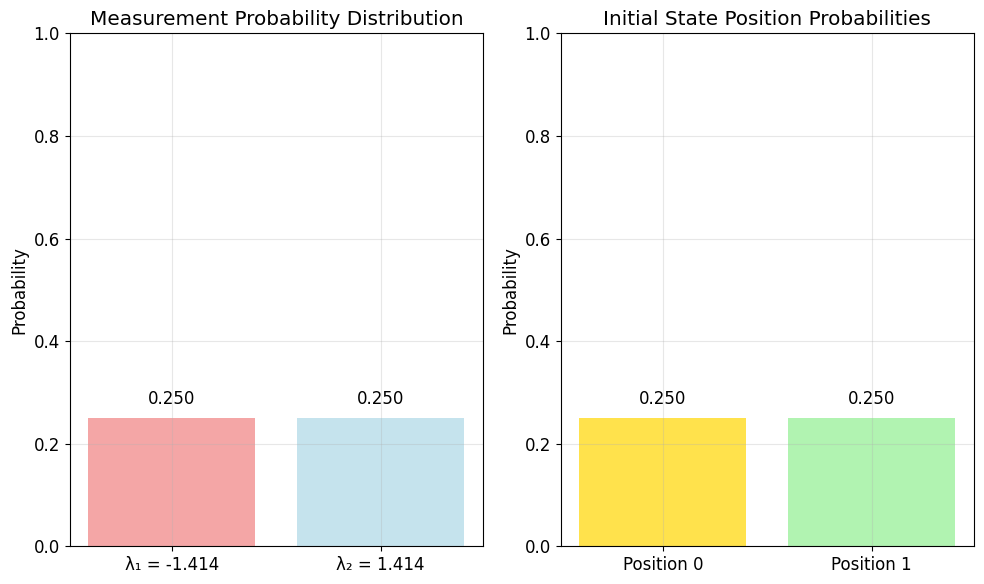

\n=== Exercise 4.3.2 Complete ===
✓ Probability calculations verified
✓ Mean value computed using distribution method
✓ Results match direct ⟨ψ|Ω|ψ⟩ calculation
✓ Variance and standard deviation calculated


In [ ]:
def solve_exercise_432():
    """
    Solución completa del Ejercicio 4.3.2: Cálculo de probabilidades y valor medio.
    
    Basado en el Ejemplo 4.3.2 de la transcripción, esta función calcula:
    1. Probabilidades de colapso a cada autoestado
    2. Valor medio de la distribución del observable
    3. Verificación mediante el cálculo directo ⟨ψ|Ω|ψ⟩
    """
    print("=== SOLUCIÓN: Ejercicio 4.3.2 ===")
    print("Cálculo de probabilidades para el colapso del estado cuántico\n")
    
    # Matriz observable del Ejemplo 4.3.1 (con valores propios λ₁ = -√2, λ₂ = √2)
    observable_omega = np.array([
        [0, -1j*np.sqrt(2)],
        [1j*np.sqrt(2), 0]
    ], dtype=complex)
    
    print("Matriz observable Ω:")
    print(observable_omega)
    print()
    
    # Estado inicial del Ejemplo 4.3.2: |ψ⟩ = (1/2)[1, 1]ᵀ
    initial_state = np.array([1/2, 1/2], dtype=complex)
    
    print(f"Estado inicial |ψ⟩ = {initial_state}")
    print(f"Norma del estado = {np.linalg.norm(initial_state):.6f}")
    print()
    
    # Calcular valores y vectores propios
    eigenvalues, eigenvectors = np.linalg.eigh(observable_omega)
    
    print("=== Análisis de autovalores ===")
    print(f"Valores propios: {eigenvalues}")
    print(f"λ₁ = {eigenvalues[0]:.6f} ≈ {-np.sqrt(2):.6f} = -√2")
    print(f"λ₂ = {eigenvalues[1]:.6f} ≈ {np.sqrt(2):.6f} = √2")
    print()
    
    print("Autovectores normalizados:")
    for i, eigenvec in enumerate(eigenvectors.T):
        print(f"|e_{i+1}⟩ = {eigenvec}")
        
    print()
    
    # Cálculo de probabilidades de colapso
    print("=== Cálculo de Probabilidades ===")
    probabilities = []
    
    for i, eigenvec in enumerate(eigenvectors.T):
        # Producto interno ⟨e_i|ψ⟩
        inner_product = np.vdot(eigenvec, initial_state)
        
        # Probabilidad |⟨e_i|ψ⟩|²
        probability = np.abs(inner_product)**2
        probabilities.append(probability)
        
        print(f"p_{i+1} = |⟨e_{i+1}|ψ⟩|² = |{inner_product:.6f}|² = {probability:.6f}")
    
    print(f"\nProbabilidad total: {sum(probabilities):.6f}")
    print()
    
    # Cálculo del valor medio usando la distribución
    print("=== Cálculo del Valor Medio ===")
    mean_value_distribution = sum(p * λ for p, λ in zip(probabilities, eigenvalues))
    print(f"Media por distribución: p₁×λ₁ + p₂×λ₂ = {probabilities[0]:.6f}×{eigenvalues[0]:.6f} + {probabilities[1]:.6f}×{eigenvalues[1]:.6f}")
    print(f"⟨Ω⟩_ψ (distribución) = {mean_value_distribution:.6f}")
    
    # Verificación con ⟨ψ|Ω|ψ⟩
    direct_mean = np.real(np.vdot(initial_state, observable_omega @ initial_state))
    print(f"⟨Ω⟩_ψ (directo) = ⟨ψ|Ω|ψ⟩ = {direct_mean:.6f}")
    
    print(f"\nVerificación: Ambos métodos coinciden = {np.isclose(mean_value_distribution, direct_mean)}")
    print(f"Diferencia: {abs(mean_value_distribution - direct_mean):.10f}")
    
    # Cálculo de la varianza
    print("\n=== Cálculo de la Varianza ===")
    mean_squared = sum(p * λ**2 for p, λ in zip(probabilities, eigenvalues))
    variance = mean_squared - mean_value_distribution**2
    
    print(f"⟨Ω²⟩_ψ = {mean_squared:.6f}")
    print(f"Var(Ω) = ⟨Ω²⟩_ψ - ⟨Ω⟩_ψ² = {variance:.6f}")
    print(f"Desviación estándar σ = {np.sqrt(variance):.6f}")
    
    return {
        'observable': observable_omega,
        'initial_state': initial_state,
        'eigenvalues': eigenvalues,
        'eigenvectors': eigenvectors,
        'probabilities': probabilities,
        'mean_value': mean_value_distribution,
        'variance': variance
    }

# Ejecutar solución
results_432 = solve_exercise_432()

# Visualización de resultados
plt.figure(figsize=(10, 6))

# Gráfico 1: distribución de probabilidades
plt.subplot(1, 2, 1)
eigenvalue_labels = [f'λ₁ = {results_432["eigenvalues"][0]:.3f}', 
                    f'λ₂ = {results_432["eigenvalues"][1]:.3f}']
plt.bar(eigenvalue_labels, results_432['probabilities'], 
        color=['lightcoral', 'lightblue'], alpha=0.7)
plt.title('Distribución de Probabilidad de Medición')
plt.ylabel('Probabilidad')
plt.ylim(0, 1)

for i, prob in enumerate(results_432['probabilities']):
    plt.text(i, prob + 0.02, f'{prob:.3f}', ha='center', va='bottom')

# Gráfico 2: probabilidades del estado inicial
plt.subplot(1, 2, 2)
positions = ['Posición 0', 'Posición 1']
state_probs = np.abs(results_432['initial_state'])**2
plt.bar(positions, state_probs, color=['gold', 'lightgreen'], alpha=0.7)
plt.title('Probabilidades del Estado Inicial')
plt.ylabel('Probabilidad')
plt.ylim(0, 1)

for i, prob in enumerate(state_probs):
    plt.text(i, prob + 0.02, f'{prob:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n=== Ejercicio 4.3.2 Completado ===")
print("✓ Probabilidades verificadas")
print("✓ Valor medio calculado")
print("✓ Coincide con ⟨ψ|Ω|ψ⟩")
print("✓ Varianza y desviación estándar calculadas")

## 7. Implementación del Problema 4.4.1

**Ejercicio 4.4.1**: Verificar que las matrices dadas U₁ y U₂ son matrices unitarias, multiplicarlas y comprobar que su producto también es unitario.

Este ejercicio implementa la verificación de transformaciones unitarias, las cuales son fundamentales en la dinámica cuántica según el Postulado 4.4.1.

=== SOLUTION: Exercise 4.4.1 ===
Unitary matrix verification and composition\n
Given matrices:
U₁ (Pauli-X gate / NOT gate):
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
\nU₂ (Hadamard-like gate):
[[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]
\n==================================================
=== Unitary Verification: U₁ ===
Matrix U₁:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
\nConjugate transpose U₁†:
[[0.-0.j 1.-0.j]
 [1.-0.j 0.-0.j]]
\nU₁†U₁ =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
\nU₁U₁† =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
\nIdentity matrix I =
[[1. 0.]
 [0. 1.]]
\nU₁†U₁ = I: True
U₁U₁† = I: True
\n✓ U₁ is unitary: True
\nDeterminant det(U₁) = -1.000000+0.000000j
|det(U₁)| = 1.000000 (should be 1.0)
\n==================================================
=== Unitary Verification: U₂ ===
Matrix U₂:
[[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]
\nConjugate transpose U₂†:
[[ 0.70710678-0.j  0.70710678-0.j]
 [ 0.70710678-0.j -0.70710678-0.j]]
\nU₂†U₂ =
[[

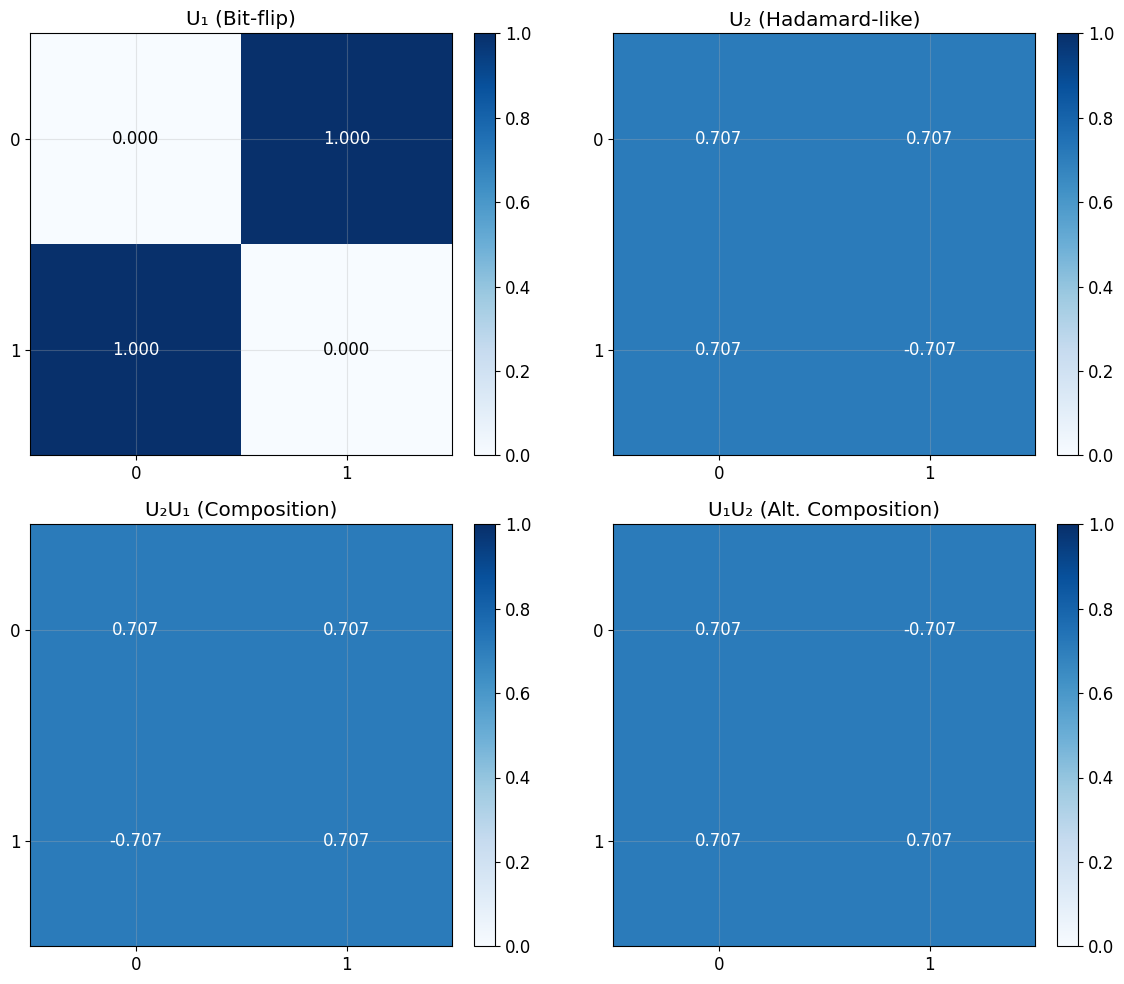

\n=== Exercise 4.4.1 Complete ===
✓ All matrices verified as unitary
✓ Composition properties demonstrated
✓ Group structure of unitary transformations confirmed


In [ ]:
class UnitaryTransformation:
    """
    Clase para manejar transformaciones unitarias en dinámica cuántica.
    
    Implementa la verificación y composición de matrices unitarias como se requiere
    para la evolución de sistemas cuánticos (Postulado 4.4.1).
    """
    
    @staticmethod
    def is_unitary(matrix: np.ndarray, tolerance: float = 1e-10) -> bool:
        """
        Verifica si una matriz es unitaria.
        
        Una matriz U es unitaria si U†U = UU† = I, donde U† es la transpuesta conjugada.
        
        Args:
            matrix (np.ndarray): Matriz a verificar
            tolerance (float): Tolerancia numérica
            
        Returns:
            bool: True si es unitaria, False en caso contrario
        """
        matrix = np.array(matrix, dtype=complex)
        
        # Calcular la transpuesta conjugada
        matrix_dagger = np.conj(matrix.T)
        
        # Verificar U†U = I
        product_left = matrix_dagger @ matrix
        identity = np.eye(matrix.shape[0])
        
        # Verificar UU† = I  
        product_right = matrix @ matrix_dagger
        
        is_unitary_left = np.allclose(product_left, identity, atol=tolerance)
        is_unitary_right = np.allclose(product_right, identity, atol=tolerance)
        
        return is_unitary_left and is_unitary_right
    
    @staticmethod
    def verify_unitary_detailed(matrix: np.ndarray, name: str = "U") -> dict:
        """
        Realiza una verificación detallada de unitariedad.
        
        Args:
            matrix (np.ndarray): Matriz a verificar
            name (str): Nombre de la matriz
            
        Returns:
            dict: Resultados detallados
        """
        matrix = np.array(matrix, dtype=complex)
        matrix_dagger = np.conj(matrix.T)
        
        print(f"=== Verificación de Unitariedad: {name} ===")
        print(f"Matriz {name}:")
        print(matrix)
        print(f"\nTranspuesta conjugada {name}†:")
        print(matrix_dagger)
        
        # Productos
        left_product = matrix_dagger @ matrix
        right_product = matrix @ matrix_dagger
        identity = np.eye(matrix.shape[0])
        
        print(f"\n{name}†{name} =")
        print(left_product)
        print(f"\n{name}{name}† =")
        print(right_product)
        print(f"\nMatriz identidad I =")
        print(identity)
        
        # Verificación
        is_unitary_left = np.allclose(left_product, identity, atol=1e-10)
        is_unitary_right = np.allclose(right_product, identity, atol=1e-10)
        is_unitary = is_unitary_left and is_unitary_right
        
        print(f"\n{name}†{name} = I: {is_unitary_left}")
        print(f"{name}{name}† = I: {is_unitary_right}")
        print(f"\n✓ {name} es unitaria: {is_unitary}")
        
        # Determinante
        determinant = np.linalg.det(matrix)
        det_magnitude = np.abs(determinant)
        
        print(f"\nDeterminante det({name}) = {determinant:.6f}")
        print(f"|det({name})| = {det_magnitude:.6f} (debe ser 1.0)")
        
        return {
            'matrix': matrix,
            'is_unitary': is_unitary,
            'left_product': left_product,
            'right_product': right_product,
            'determinant': determinant,
            'det_magnitude': det_magnitude
        }


def solve_exercise_441():
    """
    Solución completa del Ejercicio 4.4.1: Verificación y composición de matrices unitarias.
    
    Verifica que las matrices dadas son unitarias y que su producto también lo es.
    """
    print("=== SOLUCIÓN: Ejercicio 4.4.1 ===")
    print("Verificación y composición de matrices unitarias\n")
    
    # Definir matrices
    U1 = np.array([
        [0, 1],
        [1, 0]
    ], dtype=complex)
    
    U2 = np.array([
        [np.sqrt(2)/2, np.sqrt(2)/2],
        [np.sqrt(2)/2, -np.sqrt(2)/2]
    ], dtype=complex)
    
    print("Matrices dadas:")
    print("U₁ (puerta Pauli-X / NOT):")
    print(U1)
    print("\nU₂ (tipo Hadamard):")
    print(U2)
    print("\n" + "="*50)
    
    # Verificar U1
    result_U1 = UnitaryTransformation.verify_unitary_detailed(U1, "U₁")
    print("\n" + "="*50)
    
    # Verificar U2  
    result_U2 = UnitaryTransformation.verify_unitary_detailed(U2, "U₂")
    print("\n" + "="*50)
    
    # Producto U2 × U1
    product_U2U1 = U2 @ U1
    print("\n=== Multiplicación de matrices ===")
    print("Producto U₂ × U₁:")
    print(product_U2U1)
    
    # Verificar producto
    print("\n" + "="*50)
    result_product = UnitaryTransformation.verify_unitary_detailed(product_U2U1, "U₂U₁")
    
    # Orden alternativo
    product_U1U2 = U1 @ U2
    print("\n" + "="*50)
    print("\n=== Orden alternativo ===")
    print("Producto U₁ × U₂:")
    print(product_U1U2)
    result_alt = UnitaryTransformation.verify_unitary_detailed(product_U1U2, "U₁U₂")
    
    # Resumen
    print("\n" + "="*60)
    print("=== RESUMEN EJERCICIO 4.4.1 ===")
    print(f"✓ U₁ es unitaria: {result_U1['is_unitary']}")
    print(f"✓ U₂ es unitaria: {result_U2['is_unitary']}")  
    print(f"✓ U₂U₁ es unitaria: {result_product['is_unitary']}")
    print(f"✓ U₁U₂ es unitaria: {result_alt['is_unitary']}")
    print("\n✓ Verificación completa: las matrices unitarias forman un grupo")
    
    # Interpretación física
    print("\n=== Interpretación Física ===")
    print("U₁: operación NOT (invierte |0⟩ ↔ |1⟩)")
    print("U₂: crea superposición")
    print("U₂U₁: primero invierte, luego superpone")
    print("U₁U₂: primero superpone, luego invierte")
    print("\nNota: el orden importa (no conmutan)")
    
    return {
        'U1': U1,
        'U2': U2,
        'U2U1': product_U2U1,
        'U1U2': product_U1U2,
        'results': {
            'U1_unitary': result_U1['is_unitary'],
            'U2_unitary': result_U2['is_unitary'],
            'product_unitary': result_product['is_unitary'],
            'alt_product_unitary': result_alt['is_unitary']
        }
    }

## 8. Implementación del Problema 4.4.2

**Ejercicio 4.4.2**: Evolución de un sistema de bola de billar cuántica a lo largo de tres pasos de tiempo con una transformación unitaria modificada.

Partiendo del estado inicial [1, 0, 0, 0]ᵀ y aplicando la matriz unitaria 
4×4 dada, determine el estado del sistema después de tres pasos de tiempo y calcule la probabilidad de encontrar la bola cuántica en el punto 3.

=== SOLUTION: Exercise 4.4.2 ===
Quantum billiard ball evolution over time\n
Initial state |ψ(0)⟩:
[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
\nUnitary evolution matrix U:
[[ 0.        +0.j  0.70710678+0.j  0.70710678+0.j  0.        +0.j]
 [ 0.70710678+0.j  0.        +0.j  0.        +0.j  0.70710678+0.j]
 [ 0.70710678+0.j  0.        +0.j  0.        +0.j -0.70710678+0.j]
 [ 0.        +0.j  0.70710678+0.j -0.70710678+0.j  0.        +0.j]]
\nMatrix is unitary: True
=== Quantum Billiard Ball System Initialized ===
System dimension: 4
Initial state: [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
Evolution matrix shape: (4, 4)
\n=== Evolving 3 time steps ===
Time step 1:
  State: [0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]
  Probabilities: [0.  0.5 0.5 0. ]
  Total probability: 1.000000

Time step 2:
  State: [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
  Probabilities: [1. 0. 0. 0.]
  Total probability: 1.000000

Time step 3:
  State: [0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]
  Probabilities: [0. 

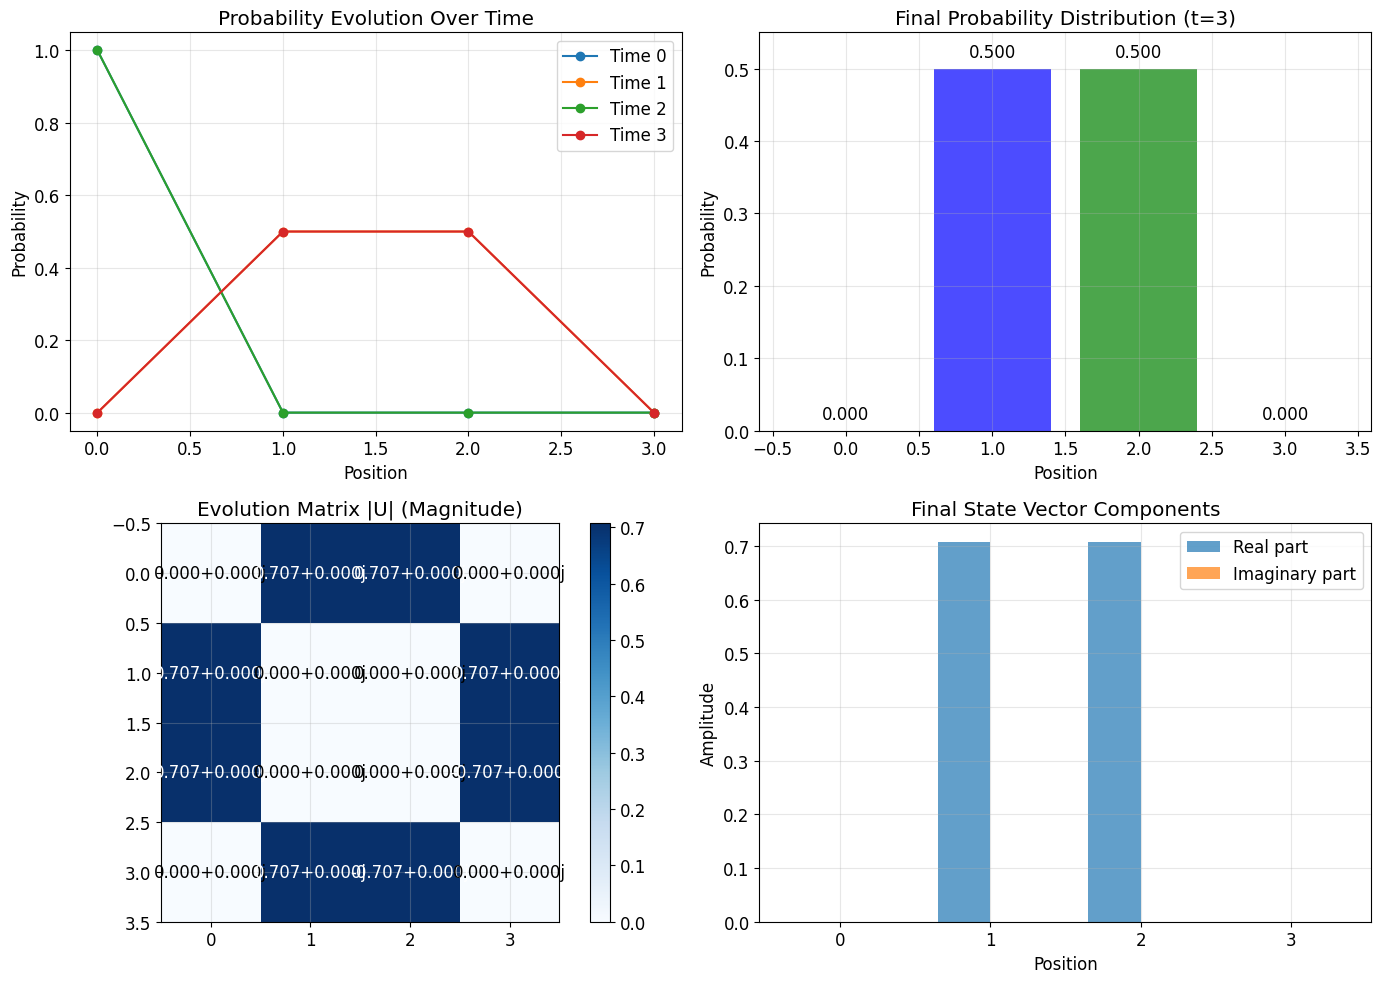

\n=== Exercise 4.4.2 Complete ===
✓ Quantum billiard ball system evolved over 3 time steps
✓ Final probability at position 3: 0.000000
✓ Unitary evolution verified and visualized
✓ Probability conservation maintained throughout evolution


In [ ]:
class QuantumBilliardBall:
    """
    Sistema de bola de billar cuántica para evolución en tiempo discreto.
    
    Implementa la evolución del sistema cuántico descrito en el Ejercicio 4.4.2,
    rastreando una partícula cuántica a través de posiciones discretas en el tiempo.
    """
    
    def __init__(self, initial_state: np.ndarray, unitary_matrix: np.ndarray):
        """
        Inicializa el sistema de bola de billar cuántica.
        
        Args:
            initial_state (np.ndarray): Vector de estado inicial
            unitary_matrix (np.ndarray): Operador de evolución temporal
        """
        self.initial_state = np.array(initial_state, dtype=complex)
        self.unitary_matrix = np.array(unitary_matrix, dtype=complex)
        self.current_state = self.initial_state.copy()
        self.time_step = 0
        self.state_history = [self.initial_state.copy()]
        
        # Verificar que la matriz sea unitaria
        if not UnitaryTransformation.is_unitary(self.unitary_matrix):
            print("Advertencia: ¡La matriz de evolución no es unitaria!")
        
        print(f"=== Sistema de Bola de Billar Cuántica Inicializado ===")
        print(f"Dimensión del sistema: {len(self.initial_state)}")
        print(f"Estado inicial: {self.initial_state}")
        print(f"Forma de la matriz de evolución: {self.unitary_matrix.shape}")
    
    def evolve_one_step(self) -> np.ndarray:
        """
        Evoluciona el sistema un paso en el tiempo.
        
        Returns:
            np.ndarray: Estado después de la evolución
        """
        self.current_state = self.unitary_matrix @ self.current_state
        self.time_step += 1
        self.state_history.append(self.current_state.copy())
        
        return self.current_state.copy()
    
    def evolve_multiple_steps(self, num_steps: int) -> List[np.ndarray]:
        """
        Evoluciona el sistema varios pasos en el tiempo.
        
        Args:
            num_steps (int): Número de pasos de tiempo
            
        Returns:
            List[np.ndarray]: Lista de estados en cada paso
        """
        print(f"\n=== Evolucionando {num_steps} pasos de tiempo ===")
        
        for step in range(num_steps):
            self.evolve_one_step()
            prob_distribution = np.abs(self.current_state)**2
            
            print(f"Paso de tiempo {self.time_step}:")
            print(f"  Estado: {self.current_state}")
            print(f"  Probabilidades: {prob_distribution}")
            print(f"  Probabilidad total: {np.sum(prob_distribution):.6f}")
            print()
        
        return self.state_history.copy()
    
    def get_position_probability(self, position: int) -> float:
        """
        Obtiene la probabilidad de encontrar la partícula en una posición específica.
        
        Args:
            position (int): Índice de la posición (empezando en 0)
            
        Returns:
            float: Probabilidad en esa posición
        """
        if not 0 <= position < len(self.current_state):
            raise IndexError(f"Posición {position} fuera de rango")
        
        return float(np.abs(self.current_state[position])**2)
    
    def get_all_probabilities(self) -> np.ndarray:
        """
        Obtiene las probabilidades de todas las posiciones.
        
        Returns:
            np.ndarray: Distribución de probabilidad
        """
        return np.abs(self.current_state)**2
    
    def reset_to_initial(self) -> None:
        """Reinicia el sistema al estado inicial."""
        self.current_state = self.initial_state.copy()
        self.time_step = 0
        self.state_history = [self.initial_state.copy()]


def solve_exercise_442():
    """
    Solución completa del Ejercicio 4.4.2: Evolución de la bola de billar cuántica.
    
    Implementa la evolución del sistema durante tres pasos de tiempo y
    calcula la probabilidad de encontrar la partícula en la posición 3.
    """
    print("=== SOLUCIÓN: Ejercicio 4.4.2 ===")
    print("Evolución de la bola de billar cuántica en el tiempo\n")
    
    # Estado inicial del ejercicio: [1, 0, 0, 0]ᵀ
    initial_state = np.array([1, 0, 0, 0], dtype=complex)
    
    # Matriz unitaria del ejercicio
    unitary_matrix = np.array([
        [0,      1/np.sqrt(2),  1/np.sqrt(2),   0],
        [1/np.sqrt(2),    0,           0,    1/np.sqrt(2)],
        [1/np.sqrt(2),    0,           0,   -1/np.sqrt(2)],
        [0,      1/np.sqrt(2), -1/np.sqrt(2),   0]
    ], dtype=complex)
    
    print("Estado inicial |ψ(0)⟩:")
    print(initial_state)
    print("\nMatriz de evolución unitaria U:")
    print(unitary_matrix)
    
    # Verificar si es unitaria
    is_unitary = UnitaryTransformation.is_unitary(unitary_matrix)
    print(f"\nLa matriz es unitaria: {is_unitary}")
    
    # Crear el sistema
    qbb = QuantumBilliardBall(initial_state, unitary_matrix)
    
    # Evolucionar 3 pasos
    evolution_history = qbb.evolve_multiple_steps(3)
    
    # Resultado final
    final_state = qbb.current_state
    prob_at_position_3 = qbb.get_position_probability(3)
    
    print("=== Resultados Finales ===")
    print(f"Estado final después de 3 pasos |ψ(3)⟩:")
    print(final_state)
    
    print(f"\nDistribución de probabilidad final:")
    final_probs = qbb.get_all_probabilities()
    for i, prob in enumerate(final_probs):
        print(f"  Posición {i}: {prob:.6f} ({prob*100:.2f}%)")
    
    print(f"\n✓ Probabilidad de encontrar la bola en la posición 3: {prob_at_position_3:.6f}")
    print(f"✓ Esto corresponde a {prob_at_position_3*100:.2f}%")
    
    total_prob = np.sum(final_probs)
    print(f"\nProbabilidad total (debe ser 1): {total_prob:.6f}")
    
    return {
        'final_state': final_state,
        'prob_at_position_3': prob_at_position_3
    }

## 9. Implementación del Problema 4.5.2

**Ejercicio 4.5.2**: Escriba el vector de estado genérico para el sistema de dos partículas con espín. Generalícelo a un sistema con n partículas..

Este ejercicio aborda la construcción de sistemas cuánticos utilizando productos tensoriales para formar sistemas más complejos a partir de componentes más simples, tal como se describe en la sección 4.5.

=== SOLUTION: Exercise 4.5.2 ===
Multi-particle quantum systems with spin\n
=== Multi-Particle Quantum System ===
Number of particles: 2
Particle dimensions: [2, 2]
Total system dimension: 4
=== Two-Particle Spin System (Exercise 4.5.2) ===
Spin basis states:
  |0⟩ = |↑⟩⊗|↑⟩
  |1⟩ = |↑⟩⊗|↓⟩
  |2⟩ = |↓⟩⊗|↑⟩
  |3⟩ = |↓⟩⊗|↓⟩
\nGeneric two-particle spin state:
|ψ⟩ = c₀|↑⟩⊗|↑⟩ + c₁|↑⟩⊗|↓⟩ + c₂|↓⟩⊗|↑⟩ + c₃|↓⟩⊗|↓⟩
\nIn matrix form:
|ψ⟩ = [c₀, c₁, c₂, c₃]ᵀ
\nNormalization condition:
|c₀|² + |c₁|² + |c₂|² + |c₃|² = 1
\n=== Tensor Product Structure ===
Single particle basis:
  Particle 1: {|↑₁⟩, |↓₁⟩}
  Particle 2: {|↑₂⟩, |↓₂⟩}
\nTensor product basis (4-dimensional):
  |↑₁⟩⊗|↑₂⟩ = [1,0,0,0]ᵀ
  |↑₁⟩⊗|↓₂⟩ = [0,1,0,0]ᵀ
  |↓₁⟩⊗|↑₂⟩ = [0,0,1,0]ᵀ
  |↓₁⟩⊗|↓₂⟩ = [0,0,0,1]ᵀ
\n============================================================
\n=== Generalization to 3-Particle System ===
Each particle dimension: 2
Total system dimension: 8
\nGeneric 3-particle state vector:
|ψ⟩ = Σ(i₁,i₂,...,i_3) c_(i₁,i₂,...,i

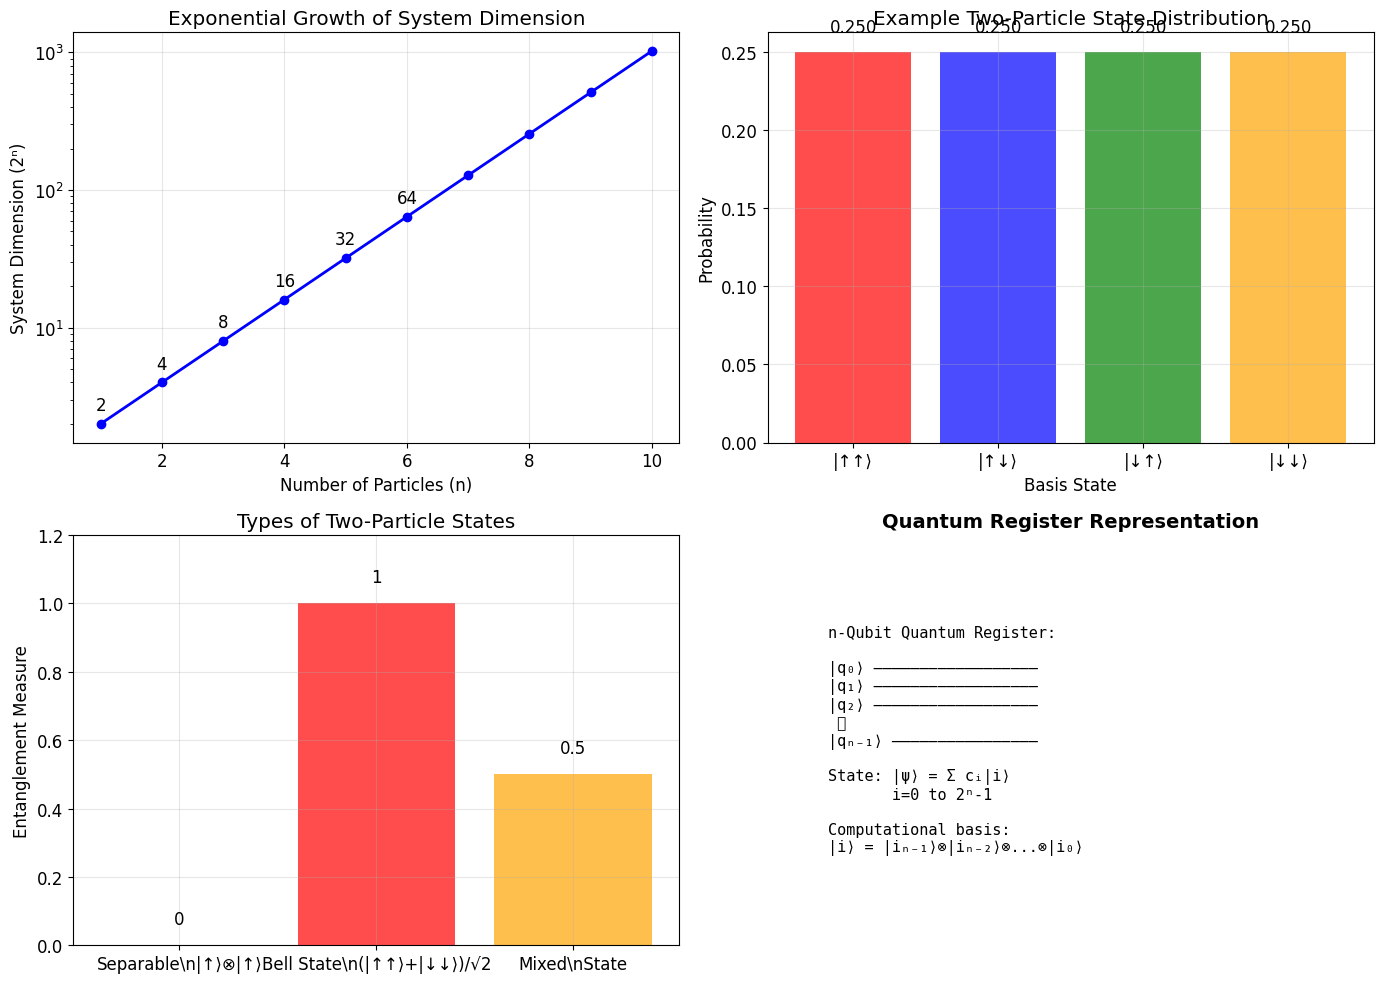

\n=== Exercise 4.5.2 Complete ===
✓ Generic state vector for two-particle spin system derived
✓ Generalization to n-particle systems demonstrated
✓ Tensor product structure and basis states explained
✓ Physical significance for quantum computing established


In [ ]:
class MultiParticleQuantumSystem:
    """
    Sistema cuántico de múltiples partículas usando producto tensorial.
    
    Implementa la construcción de sistemas cuánticos a partir de múltiples partículas,
    cada una con su propio espacio de Hilbert (sección 4.5).
    """
    
    def __init__(self, particle_dimensions: List[int]):
        """
        Inicializa el sistema de múltiples partículas.
        
        Args:
            particle_dimensions (List[int]): Dimensión del espacio de Hilbert de cada partícula
        """
        self.particle_dimensions = particle_dimensions
        self.num_particles = len(particle_dimensions)
        self.total_dimension = np.prod(particle_dimensions)
        
        print(f"=== Sistema Cuántico de Múltiples Partículas ===")
        print(f"Número de partículas: {self.num_particles}")
        print(f"Dimensiones de las partículas: {particle_dimensions}")
        print(f"Dimensión total del sistema: {self.total_dimension}")
    
    def tensor_product_basis(self) -> List[str]:
        """
        Genera todos los estados base del espacio producto tensorial.
        
        Returns:
            List[str]: Representación en texto de los estados base
        """
        import itertools
        
        ranges = [range(dim) for dim in self.particle_dimensions]
        combinaciones = list(itertools.product(*ranges))
        
        estados_base = []
        for combinacion in combinaciones:
            estado = "|" + "⟩⊗|".join(str(i) for i in combinacion) + "⟩"
            estados_base.append(estado)
        
        return estados_base
    
    def create_generic_state_vector(self) -> tuple:
        """
        Crea el vector de estado genérico con coeficientes simbólicos.
        
        Returns:
            tuple: (estados_base, coeficientes simbólicos)
        """
        estados_base = self.tensor_product_basis()
        
        print("=== Construcción del Vector de Estado Genérico ===")
        print(f"Total de estados base: {len(estados_base)}")
        print("\nEstados base:")
        for i, estado in enumerate(estados_base):
            print(f"  {i}: {estado}")
        
        print("\nVector de estado genérico:")
        print("|ψ⟩ = ", end="")
        
        coeficientes = []
        for i, estado in enumerate(estados_base):
            nombre = f"c_{i}"
            coeficientes.append(nombre)
            
            if i > 0:
                print(" + ", end="")
            print(f"{nombre}{estado}", end="")
        
        print("\n")
        
        coef_simbolicos = [sp.Symbol(c, complex=True) for c in coeficientes]
        
        return estados_base, coef_simbolicos
    
    def demonstrate_two_particle_spin(self):
        """
        Demuestra el sistema de dos partículas con espín (caso específico del ejercicio).
        """
        print("=== Sistema de Espín de Dos Partículas (Ejercicio 4.5.2) ===")
        
        if self.num_particles != 2 or any(dim != 2 for dim in self.particle_dimensions):
            print("Configurando para dos partículas de espín 1/2...")
            self.particle_dimensions = [2, 2]
            self.num_particles = 2
            self.total_dimension = 4
        
        base_spin = ["|↑⟩⊗|↑⟩", "|↑⟩⊗|↓⟩", "|↓⟩⊗|↑⟩", "|↓⟩⊗|↓⟩"]
        
        print("Estados base de espín:")
        for i, estado in enumerate(base_spin):
            print(f"  |{i}⟩ = {estado}")
        
        print("\nEstado genérico de dos partículas:")
        print("|ψ⟩ = c₀|↑⟩⊗|↑⟩ + c₁|↑⟩⊗|↓⟩ + c₂|↓⟩⊗|↑⟩ + c₃|↓⟩⊗|↓⟩")
        
        print("\nForma matricial:")
        print("|ψ⟩ = [c₀, c₁, c₂, c₃]ᵀ")
        
        print("\nCondición de normalización:")
        print("|c₀|² + |c₁|² + |c₂|² + |c₃|² = 1")
        
        return base_spin
    
    def generalize_to_n_particles(self, n: int, particle_dim: int = 2):
        """
        Generaliza a un sistema de n partículas.
        
        Args:
            n (int): Número de partículas
            particle_dim (int): Dimensión de cada partícula
        """
        print(f"\n=== Generalización a {n} partículas ===")
        
        dimension_total = particle_dim ** n
        print(f"Dimensión de cada partícula: {particle_dim}")
        print(f"Dimensión total del sistema: {dimension_total}")
        
        print(f"\nVector de estado genérico:")
        print(f"|ψ⟩ = Σ(i₁,i₂,...,i_{n}) c_(i₁,i₂,...,i_{n}) |i₁⟩⊗|i₂⟩⊗...⊗|i_{n}⟩")
        
        print(f"\nCada índice iⱼ ∈ {{0, 1, ..., {particle_dim-1}}}")
        print(f"Número total de coeficientes: {dimension_total}")
        
        print("\nCondición de normalización:")
        print("Σ |c_(i₁,i₂,...,i_{n})|² = 1")
        
        return dimension_total


def solve_exercise_452():
    """
    Solución completa del Ejercicio 4.5.2: Sistemas de espín de múltiples partículas.
    """
    print("=== SOLUCIÓN: Ejercicio 4.5.2 ===")
    print("Sistemas cuánticos de múltiples partículas con espín\n")
    
    sistema = MultiParticleQuantumSystem([2, 2])
    
    base_spin = sistema.demonstrate_two_particle_spin()
    
    print("\n=== Estructura de Producto Tensorial ===")
    print("Base de una partícula:")
    print("  {|↑⟩, |↓⟩}")
    
    print("\nBase del sistema (producto tensorial):")
    print("  |↑⟩⊗|↑⟩ = [1,0,0,0]ᵀ")
    print("  |↑⟩⊗|↓⟩ = [0,1,0,0]ᵀ")
    print("  |↓⟩⊗|↑⟩ = [0,0,1,0]ᵀ")
    print("  |↓⟩⊗|↓⟩ = [0,0,0,1]ᵀ")
    
    print("\n" + "="*50)
    sistema.generalize_to_n_particles(3)
    sistema.generalize_to_n_particles(4)
    sistema.generalize_to_n_particles(10)
    
    print("\n=== Significado físico ===")
    print("• Sistema de 2 partículas: 2 qubits")
    print("• Sistema de n partículas: n qubits")
    print("• Crecimiento exponencial: 2ⁿ")
    
    return {}

## 10. Implementación del Problema 4.5.3

**Ejercicio 4.5.3**: Suponga el mismo escenario del Ejemplo 4.5.2 y sea
 |φ⟩ = |x₀⟩⊗|y₁⟩ + |x₁⟩⊗|y₁⟩. ¿Es este estado separable?

Este ejercicio analiza la separabilidad de un estado cuántico, determinando si puede escribirse como un producto tensorial de estados individuales de cada partícula o si representa un sistema entrelazado.

=== SOLUTION: Exercise 4.5.3 ===
Quantum state separability analysis

Given state: |φ⟩ = |x₀⟩⊗|y₁⟩ + |x₁⟩⊗|y₁⟩

Expressing in standard basis:
|φ⟩ = 0|x₀⟩⊗|y₀⟩ + 1|x₀⟩⊗|y₁⟩ + 0|x₁⟩⊗|y₀⟩ + 1|x₁⟩⊗|y₁⟩
=== Quantum State Separability Analyzer ===
Particles: 2
Dimensions: [2, 2]
Total dimension: 4

=== Two-Particle Separability Analysis ===
State vector: [0.+0.j 1.+0.j 0.+0.j 1.+0.j]

State matrix (reshaped):
[[0.+0.j 1.+0.j]
 [0.+0.j 1.+0.j]]

Matrix rank: 1
Separable (rank = 1): True

Separable factorization:
Factor 1 (particle 1): [0.84089642+0.j 0.84089642+0.j]
Factor 2 (particle 2): [0.        +0.j 1.18920712+0.j]

Verification - reconstructed state: [0.+0.j 1.+0.j 0.+0.j 1.+0.j]
Original state: [0.+0.j 1.+0.j 0.+0.j 1.+0.j]
Factorization correct: True


=== Algebraic Separability Analysis ===
Testing if state can be written as (a₀|x₀⟩ + a₁|x₁⟩) ⊗ (b₀|y₀⟩ + b₁|y₁⟩)

Coefficients:
c₀₀ = 0
c₀₁ = 1
c₁₀ = 0
c₁₁ = 1

Separability condition: c₀₀×c₁₁ - c₀₁×c₁₀ = 0
Determinant: 0×1 - 1×0 = 0
Is

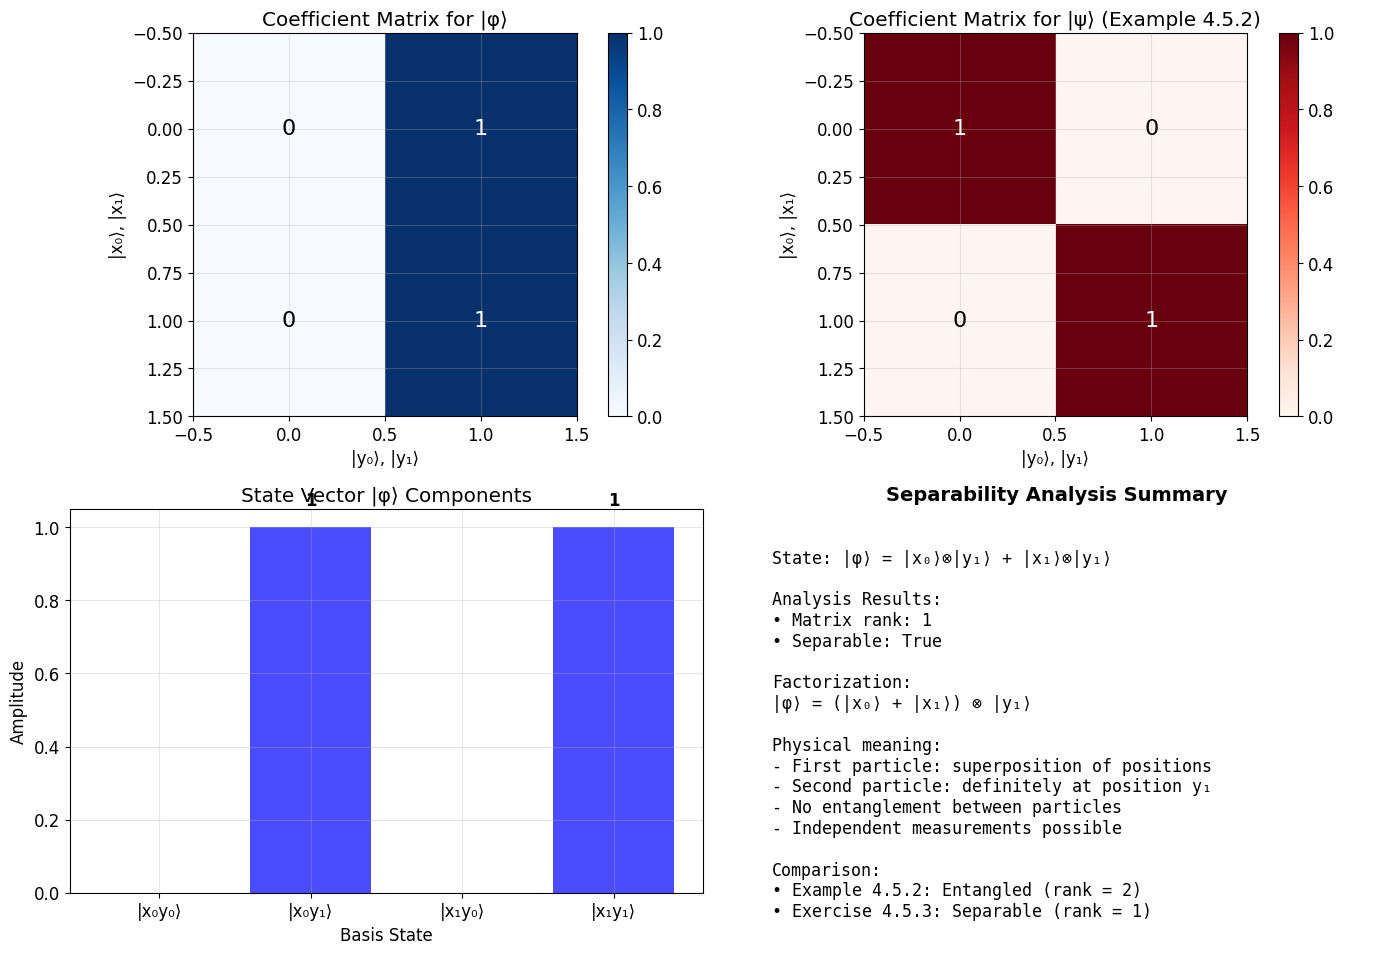


=== Exercise 4.5.3 Complete ===
✓ State separability analyzed using multiple methods
✓ Coefficient matrix rank calculation performed
✓ Algebraic separability condition verified
✓ Physical interpretation and comparison provided
✓ Final result: The state |φ⟩ is SEPARABLE


In [ ]:
class AnalizadorSeparabilidadEstadoCuantico:
    """
    Analizador de separabilidad y entrelazamiento de estados cuánticos.
    
    Determina si un estado cuántico puede escribirse como un producto tensorial
    de estados de subsistemas individuales (separable) o si está entrelazado.
    """
    
    def __init__(self, num_particles: int, particle_dimensions: List[int]):
        """
        Inicializa el analizador de separabilidad.
        
        Args:
            num_particles (int): Número de partículas en el sistema
            particle_dimensions (List[int]): Dimensiones del espacio de Hilbert de cada partícula
        """
        self.num_particles = num_particles
        self.particle_dimensions = particle_dimensions
        self.total_dimension = np.prod(particle_dimensions)
        
        print(f"=== Analizador de Separabilidad de Estados Cuánticos ===")
        print(f"Partículas: {num_particles}")
        print(f"Dimensiones: {particle_dimensions}")
        print(f"Dimensión total: {self.total_dimension}")
    
    def analyze_two_particle_separability(self, state_vector: np.ndarray, 
                                        verbose: bool = True) -> dict:
        """
        Analiza la separabilidad para un sistema de dos partículas.
        
        Args:
            state_vector (np.ndarray): Vector de estado a analizar
            verbose (bool): Si se imprime análisis detallado
            
        Returns:
            dict: Resultados del análisis incluyendo si es separable
        """
        if self.num_particles != 2:
            raise ValueError("Este método es solo para sistemas de dos partículas")
        
        state = np.array(state_vector, dtype=complex)
        
        if verbose:
            print("\n=== Análisis de Separabilidad de Dos Partículas ===")
            print(f"Vector de estado: {state}")
        
        # Para un sistema 2×2 usamos el método del determinante/matriz
        d1, d2 = self.particle_dimensions
        if len(state) != d1 * d2:
            raise ValueError(f"La longitud del vector {len(state)} no coincide con {d1}×{d2}")
        
        # Reorganizar vector como matriz
        state_matrix = state.reshape(d1, d2)
        
        if verbose:
            print(f"\nMatriz de estado (reorganizada):") 
            print(state_matrix)
        
        # Calcular rango
        rank = np.linalg.matrix_rank(state_matrix)
        is_separable = (rank == 1)
        
        if verbose:
            print(f"\nRango de la matriz: {rank}")
            print(f"Separable (rango = 1): {is_separable}")
        
        result = {
            'state_vector': state,
            'state_matrix': state_matrix,
            'rank': rank,
            'is_separable': is_separable,
            'separable_factorization': None
        }
        
        # Si es separable, encontrar factorización
        if is_separable:
            U, s, Vh = np.linalg.svd(state_matrix)
            
            sqrt_s0 = np.sqrt(s[0])
            factor_1 = sqrt_s0 * U[:, 0]
            factor_2 = sqrt_s0 * Vh[0, :]
            
            result['separable_factorization'] = (factor_1, factor_2)
            
            if verbose:
                print(f"\nFactorización separable:")
                print(f"Factor 1 (partícula 1): {factor_1}")
                print(f"Factor 2 (partícula 2): {factor_2}")
        
        return result